# 07. Top-20 Feature Budget Extension
Step 6의 상위 1~10개 결과를 재사용하고 동일 조건으로 11~20개 누적 조합을 추가 검증합니다. 상위 20개로 확장했을 때 9개 optimum과 선형성 결론이 유지되는지 확인합니다.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))
REPORT_DIR = PROJECT_ROOT / 'reports'

from src.secom_analysis import load_secom
from src.modeling import build_baseline_models
from src.feature_budget import cumulative_feature_budget_experiment, feature_budget_conclusions

## 1. Integrated-evidence top 20

In [2]:
evidence = pd.read_csv(REPORT_DIR / 'candidate_feature_evidence.csv')
top_features = evidence.head(20)['feature'].tolist()
ranking = pd.DataFrame({'rank': range(1, 21), 'feature': top_features})
ranking.to_csv(REPORT_DIR / 'feature_budget_ranking_top20.csv', index=False)
display(ranking)

,rank,feature
0,1,feature_59
1,2,feature_129
2,3,feature_125
3,4,feature_205
4,5,feature_519
5,6,feature_477
6,7,feature_247
7,8,feature_130
8,9,feature_33
9,10,feature_452


## 2. Extend the cumulative experiment from k=11 to k=20
모델, CV split, temporal split, tokenizer 설정은 Step 6과 동일합니다. 실행시간은 측정 세션에 따라 변동할 수 있으므로 절대값보다 규모와 선형성 여부를 중심으로 해석합니다.

In [3]:
previous = pd.read_csv(REPORT_DIR / 'feature_budget_comparison.csv')
X, labels = load_secom(PROJECT_ROOT / 'data/raw')
model = build_baseline_models()['random_forest_balanced']
extension = cumulative_feature_budget_experiment(
    model, X, labels['is_fail'], labels['timestamp'], top_features,
    n_splits=5, n_repeats=3, inference_repeats=30, min_feature_count=11
)
raw_results = pd.concat([previous[extension.columns], extension], ignore_index=True).sort_values('feature_count')
results, linearity, optimum = feature_budget_conclusions(raw_results)
results.to_csv(REPORT_DIR / 'feature_budget_comparison_top20.csv', index=False)
linearity.to_csv(REPORT_DIR / 'feature_budget_linearity_top20.csv', index=False)
optimum.to_csv(REPORT_DIR / 'feature_budget_optimum_top20.csv', index=False)
display(results)
display(linearity)
display(optimum)

,feature_count,features,added_feature,cv_pr_auc_mean,cv_pr_auc_std,cv_pr_auc_sem,cv_roc_auc_mean,cv_balanced_accuracy_mean,temporal_test_pr_auc,fit_time_mean_seconds,...,tokens_mean_per_sample,tokens_std_per_sample,tokens_total_dataset,json_encoding,token_scope,token_multiplier_vs_top1,pr_auc_gain_vs_top1,marginal_pr_auc_gain,marginal_tokens,marginal_pr_auc_per_100_tokens
0,1,feature_59,feature_59,0.106408,0.023503,0.006068,0.598588,0.532065,0.053535,2.383170,...,9.895341,0.347253,15506,cl100k_base,feature-value JSON only; prompt overhead excluded,1.000000,0.000000,NaN,NaN,NaN
1,2,"feature_59,feature_129",feature_129,0.130035,0.024677,0.006372,0.666671,0.516773,0.055662,1.883555,...,18.490747,0.640091,28975,cl100k_base,feature-value JSON only; prompt overhead excluded,1.868631,0.023627,0.023627,8.595405,0.274883
2,3,"feature_59,feature_129,feature_125",feature_125,0.150238,0.031804,0.008212,0.695297,0.521570,0.074404,1.556089,...,26.760051,0.838025,41933,cl100k_base,feature-value JSON only; prompt overhead excluded,2.704308,0.043830,0.020203,8.269304,0.244307
3,4,"feature_59,feature_129,feature_125,feature_205",feature_205,0.191261,0.065131,0.016817,0.700390,0.525464,0.069941,2.227421,...,34.752393,0.874620,54457,cl100k_base,feature-value JSON only; prompt overhead excluded,3.511995,0.084853,0.041023,7.992342,0.513281
4,5,"feature_59,feature_129,feature_125,feature_205...",feature_519,0.190765,0.058188,0.015024,0.718825,0.518065,0.078233,1.849392,...,42.333121,1.800403,66336,cl100k_base,feature-value JSON only; prompt overhead excluded,4.278086,0.084356,-0.000497,7.580728,-0.006551
5,6,"feature_59,feature_129,feature_125,feature_205...",feature_477,0.210660,0.061294,0.015826,0.726004,0.527367,0.086087,1.817941,...,51.223357,1.864473,80267,cl100k_base,feature-value JSON only; prompt overhead excluded,5.176512,0.104252,0.019896,8.890236,0.223793
6,7,"feature_59,feature_129,feature_125,feature_205...",feature_247,0.206496,0.061098,0.015775,0.723555,0.525746,0.092153,1.989914,...,58.795150,3.179320,92132,cl100k_base,feature-value JSON only; prompt overhead excluded,5.941700,0.100088,-0.004164,7.571793,-0.055000
7,8,"feature_59,feature_129,feature_125,feature_205...",feature_130,0.210716,0.062317,0.016090,0.741069,0.522492,0.129267,1.585553,...,67.667518,3.227415,106035,cl100k_base,feature-value JSON only; prompt overhead excluded,6.838321,0.104308,0.004220,8.872368,0.047565
8,9,"feature_59,feature_129,feature_125,feature_205...",feature_33,0.244574,0.061015,0.015754,0.767776,0.522533,0.155330,1.963602,...,76.555839,3.254711,119963,cl100k_base,feature-value JSON only; prompt overhead excluded,7.736554,0.138165,0.033858,8.888322,0.380922
9,10,"feature_59,feature_129,feature_125,feature_205...",feature_452,0.244369,0.055144,0.014238,0.757113,0.517692,0.161495,1.797906,...,85.455010,3.266629,133908,cl100k_base,feature-value JSON only; prompt overhead excluded,8.635883,0.137960,-0.000205,8.899170,-0.002303


,metric,slope_per_added_feature,intercept,linear_r_squared,approximately_linear_r2_ge_0_90
0,cv_pr_auc_mean,0.005373,0.154540,0.642216,False
1,temporal_test_pr_auc,0.004331,0.075895,0.307035,False
2,fit_time_mean_seconds,0.003154,1.903437,0.009404,False
3,inference_time_ms_per_sample,-0.003371,0.246683,0.248274,False
4,tokens_mean_per_sample,8.659157,-0.237641,0.999683,True


,criterion,feature_count,features,cv_pr_auc_mean,cv_pr_auc_sem,tokens_mean_per_sample,fit_time_mean_seconds
0,maximum_mean_cv_pr_auc,9,"feature_59,feature_129,feature_125,feature_205...",0.244574,0.015754,76.555839,1.963602
1,one_standard_error_simplest,9,"feature_59,feature_129,feature_125,feature_205...",0.244574,0.015754,76.555839,1.963602


## 3. Top-20 performance-cost curves

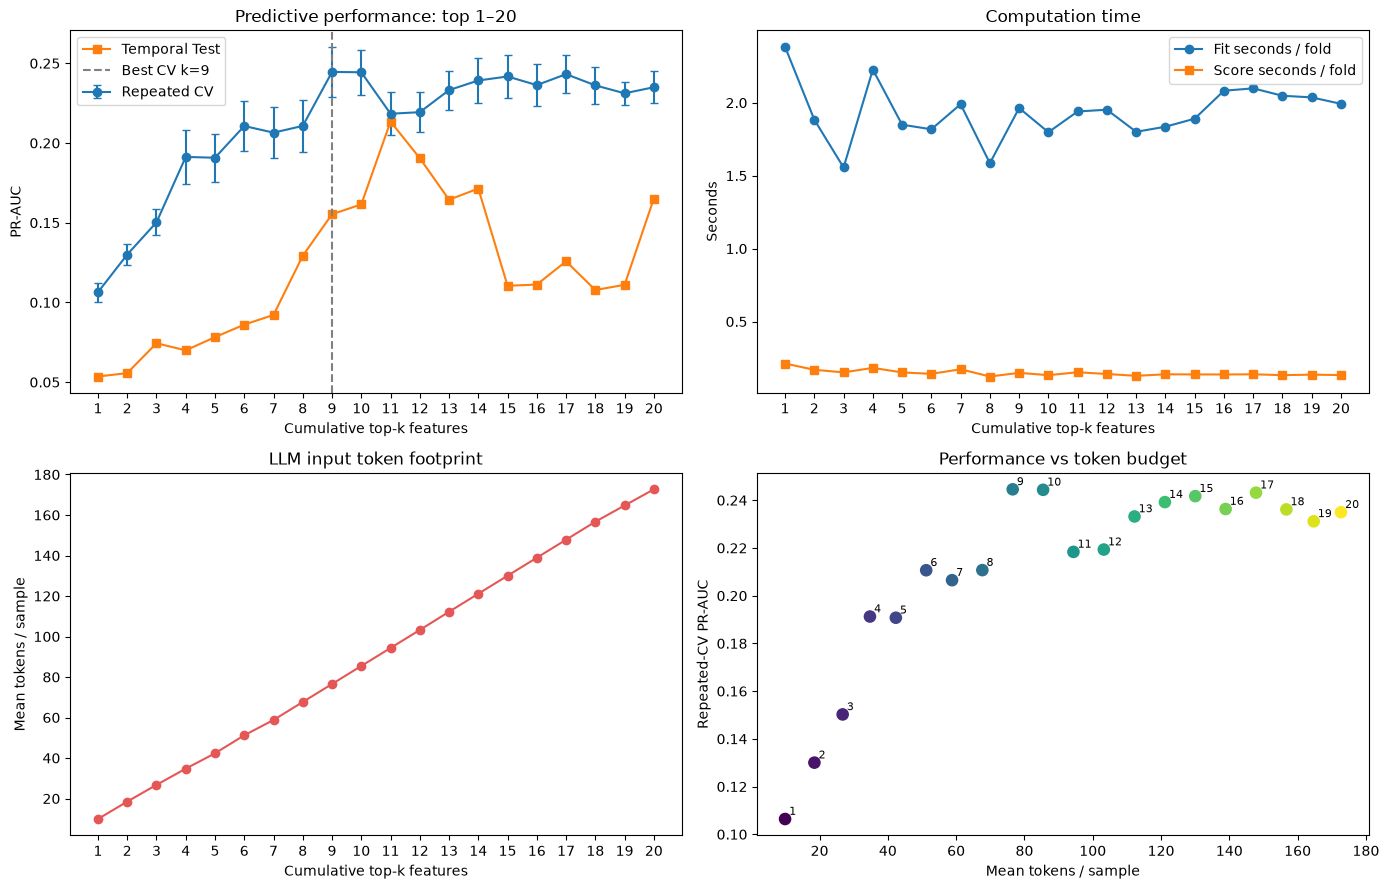

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
x = results['feature_count']
best_k = int(optimum.loc[optimum['criterion'].eq('maximum_mean_cv_pr_auc'), 'feature_count'].iloc[0])

axes[0, 0].errorbar(x, results['cv_pr_auc_mean'], yerr=results['cv_pr_auc_sem'], marker='o', capsize=3, label='Repeated CV')
axes[0, 0].plot(x, results['temporal_test_pr_auc'], marker='s', label='Temporal Test')
axes[0, 0].axvline(best_k, color='gray', linestyle='--', label=f'Best CV k={best_k}')
axes[0, 0].set(title='Predictive performance: top 1–20', xlabel='Cumulative top-k features', ylabel='PR-AUC', xticks=range(1, 21))
axes[0, 0].legend()

axes[0, 1].plot(x, results['fit_time_mean_seconds'], marker='o', label='Fit seconds / fold')
axes[0, 1].plot(x, results['score_time_mean_seconds'], marker='s', label='Score seconds / fold')
axes[0, 1].set(title='Computation time', xlabel='Cumulative top-k features', ylabel='Seconds', xticks=range(1, 21))
axes[0, 1].legend()

axes[1, 0].plot(x, results['tokens_mean_per_sample'], marker='o', color='#E45756')
axes[1, 0].set(title='LLM input token footprint', xlabel='Cumulative top-k features', ylabel='Mean tokens / sample', xticks=range(1, 21))

axes[1, 1].scatter(results['tokens_mean_per_sample'], results['cv_pr_auc_mean'], c=x, cmap='viridis', s=65)
for _, row in results.iterrows():
    axes[1, 1].annotate(int(row['feature_count']), (row['tokens_mean_per_sample'], row['cv_pr_auc_mean']), xytext=(3, 3), textcoords='offset points', fontsize=8)
axes[1, 1].set(title='Performance vs token budget', xlabel='Mean tokens / sample', ylabel='Repeated-CV PR-AUC')

fig.tight_layout()
fig.savefig(REPORT_DIR / 'feature_budget_efficiency_top20.png', dpi=170)
plt.show()

## 4. Conclusions
- **CV 성능·토큰 효율 기준 optimum 9개는 유지됐습니다.** 평균 CV PR-AUC 최고점과 one-standard-error rule 모두 9개를 선택했습니다.
- **선형성 결론은 유지되지 않았습니다.** CV PR-AUC의 선형 R²는 top 1–10의 0.917에서 top 1–20의 0.642로 낮아졌습니다. 9개 이후에는 포화와 비단조 변동이 나타납니다.
- 토큰량은 top 1–20에서도 R² 0.9997로 거의 완전 선형 증가합니다.
- 20개는 9개보다 토큰을 125.6% 더 사용하지만 CV PR-AUC는 0.0096 낮습니다.
- Temporal PR-AUC 최고점은 11개(0.21345)입니다. 11번째 feature_510이 특정 미래 구간에는 도움이 됐지만 CV PR-AUC는 0.21836으로 낮아 일반화가 불안정합니다.
- 운영 후보는 9개 기본안과 11개 temporal 후보안을 rolling backtest로 재검증하는 것이 적절합니다.
- 현재 순위는 전체 데이터에서 파생된 탐색 결과이므로 절대 성능은 낙관적일 수 있습니다. 배포 성능 추정에는 nested feature selection이 필요합니다.